### The following cell contains a bunch of functions for reading BED files, computing overlap, computing accuracy metrics, and plotting. Matplotlib is required.

In [30]:
from typing import List, Tuple, Dict

Interval = Tuple[int, int]          # (start, end)
ChromIntervals = Dict[str, List[Interval]]  # chrom -> list of (start, end)

def read_bed(path: str) -> ChromIntervals:
    """
    Read a BED file into a dict: chrom -> list of (start, end) intervals.
    Ignores extra columns and comment/empty lines.
    """
    data: ChromIntervals = {}
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            fields = line.split()
            chrom, start, end = fields[0], int(fields[1]), int(fields[2])
            data.setdefault(chrom, []).append((start, end))
    return data


def merge_intervals(intervals: List[Interval]) -> List[Interval]:
    """
    Merge overlapping or adjacent intervals.
    Assumes 0-based, half-open [start, end).
    """
    if not intervals:
        return []

    intervals = sorted(intervals, key=lambda x: (x[0], x[1]))
    merged: List[Interval] = []
    cur_start, cur_end = intervals[0]

    for s, e in intervals[1:]:
        if s <= cur_end:  # overlap or directly adjacent
            cur_end = max(cur_end, e)
        else:
            merged.append((cur_start, cur_end))
            cur_start, cur_end = s, e

    merged.append((cur_start, cur_end))
    return merged


def total_bases(intervals: List[Interval]) -> int:
    """Total length of (already merged) intervals."""
    return sum(e - s for s, e in intervals)


def overlap_length(ivals1: List[Interval], ivals2: List[Interval]) -> int:
    """
    Compute total overlap length between two *merged* interval lists
    on a single chromosome.
    Two-pointer sweep; runs in O(n + m).
    """
    i = j = 0
    total = 0

    while i < len(ivals1) and j < len(ivals2):
        s1, e1 = ivals1[i]
        s2, e2 = ivals2[j]

        # overlap between [s1, e1) and [s2, e2)
        start = max(s1, s2)
        end = min(e1, e2)
        if start < end:
            total += end - start

        # advance the interval that ends first
        if e1 <= e2:
            i += 1
        else:
            j += 1

    return total


def compare_beds(bed1_path: str, bed2_path: str):
    """
    Given two BED files, return:
      1) total bases present in bed1
      2) total bases present in bed2
      3) total bases in their overlap
      4) total bases exclusive to bed1
      5) total bases exclusive to bed2
    """
    bed1_raw = read_bed(bed1_path)
    bed2_raw = read_bed(bed2_path)

    # Merge intervals per chromosome
    bed1_merged: ChromIntervals = {
        chrom: merge_intervals(iv) for chrom, iv in bed1_raw.items()
    }
    bed2_merged: ChromIntervals = {
        chrom: merge_intervals(iv) for chrom, iv in bed2_raw.items()
    }

    # 1 & 2: total bases in each BED
    total1 = sum(total_bases(iv) for iv in bed1_merged.values())
    total2 = sum(total_bases(iv) for iv in bed2_merged.values())

    # 3: overlap
    overlap = 0
    for chrom in set(bed1_merged.keys()).union(bed2_merged.keys()):
        iv1 = bed1_merged.get(chrom, [])
        iv2 = bed2_merged.get(chrom, [])
        if not iv1 or not iv2:
            continue
        overlap += overlap_length(iv1, iv2)

    # 4 & 5: exclusive bases
    exclusive1 = total1 - overlap
    exclusive2 = total2 - overlap

    return {
        "total_bed1": total1,
        "total_bed2": total2,
        "overlap": overlap,
        "exclusive_bed1": exclusive1,
        "exclusive_bed2": exclusive2,
    }

def compute_metrics(stats1, stats2):
    tp1 = stats1["overlap"]
    fn1 = stats1["exclusive_bed1"]
    fp1 = stats1["exclusive_bed2"]

    tp2 = stats2["overlap"]
    fn2 = stats2["exclusive_bed1"]
    fp2 = stats2["exclusive_bed2"]

    precision = (tp1+tp2) / (tp1 + fp1 + tp2 + fp2) 
    recall    = (tp1 + tp2) / (tp1 + fn1 + tp2 + fn2) 

    f1 = 2 * (precision * recall) / (precision + recall)

    combined_size = 47311724 + 44312598
    percentage = (tp1 + fn1 + tp2 + fn2)/combined_size
    return {
        "combined precision": precision,
        "combined recall": recall,
        "combined f1": f1,
        "combined masking proportion": percentage
    }

def calculate_bed_coverage(bed_file, sequence_lengths):
    """
    Calculate the number and percentage of bases covered by a BED file.
    
    Parameters
    ----------
    bed_file : str
        Path to the BED file.
    sequence_lengths : dict or int
        If dict: sequence IDs as keys and lengths as values
        If int: total sequence length (assumes single sequence)
        
    Returns
    -------
    dict
        Dictionary containing coverage statistics:
        - total_covered_bases: Total number of bases covered
        - total_sequence_length: Total sequence length
        - coverage_percentage: Percentage of sequence covered
        - per_sequence_stats: Per-sequence statistics (if dict provided)
    """
    
    def load_bed_intervals(bed_file):
        """Load BED file and return intervals per chromosome."""
        intervals = {}
        with open(bed_file, 'r') as f:
            for line in f:
                line = line.strip()
                if line.startswith('#') or not line:
                    continue
                parts = line.split('\t')
                if len(parts) < 3:
                    continue
                
                chrom = parts[0]
                start = int(parts[1])
                end = int(parts[2])
                
                if chrom not in intervals:
                    intervals[chrom] = []
                intervals[chrom].append((start, end))
        
        return intervals
    
    def merge_overlapping_intervals(intervals):
        """Merge overlapping intervals to avoid double-counting."""
        if not intervals:
            return []
        
        # Sort intervals by start position
        intervals.sort()
        merged = []
        current_start, current_end = intervals[0]
        
        for start, end in intervals[1:]:
            if start <= current_end:
                # Overlapping intervals, merge them
                current_end = max(current_end, end)
            else:
                # Non-overlapping interval, save current and start new
                merged.append((current_start, current_end))
                current_start, current_end = start, end
        
        # Add the last interval
        merged.append((current_start, current_end))
        return merged
    
    def calculate_interval_coverage(intervals):
        """Calculate total bases covered by intervals."""
        merged = merge_overlapping_intervals(intervals)
        return sum(end - start for start, end in merged)
    
    # Load BED intervals
    bed_intervals = load_bed_intervals(bed_file)
    
    # Handle different input types for sequence_lengths
    if isinstance(sequence_lengths, dict):
        total_sequence_length = sum(sequence_lengths.values())
        per_sequence_stats = {}
        
        # Calculate coverage per sequence
        total_covered_bases = 0
        for seq_id, seq_length in sequence_lengths.items():
            if seq_id in bed_intervals:
                covered_bases = calculate_interval_coverage(bed_intervals[seq_id])
            else:
                covered_bases = 0
            
            coverage_pct = (covered_bases / seq_length * 100) if seq_length > 0 else 0
            per_sequence_stats[seq_id] = {
                'sequence_length': seq_length,
                'covered_bases': covered_bases,
                'coverage_percentage': coverage_pct
            }
            total_covered_bases += covered_bases
            
    else:  # Assume it's an integer (single sequence)
        total_sequence_length = sequence_lengths
        per_sequence_stats = None
        
        # Calculate total coverage across all intervals
        total_covered_bases = 0
        for chrom, intervals in bed_intervals.items():
            total_covered_bases += calculate_interval_coverage(intervals)
    
    # Calculate overall coverage percentage
    overall_coverage_pct = (total_covered_bases / total_sequence_length * 100) if total_sequence_length > 0 else 0
    
    return {
        'total_covered_bases': total_covered_bases,
        'total_sequence_length': total_sequence_length,
        'coverage_percentage': overall_coverage_pct,
        'per_sequence_stats': per_sequence_stats
    }

def print_bed_coverage_summary(coverage_stats):
    """
    Print a formatted summary of BED file coverage statistics.
    
    Parameters
    ----------
    coverage_stats : dict
        Dictionary returned by calculate_bed_coverage()
    """
    print("BED File Coverage Summary:")
    print("=" * 50)
    print(f"Total sequence length: {coverage_stats['total_sequence_length']:,} bp")
    print(f"Total covered bases: {coverage_stats['total_covered_bases']:,} bp")
    print(f"Overall coverage: {coverage_stats['coverage_percentage']:.2f}%")
    
    if coverage_stats['per_sequence_stats']:
        print("\nPer-sequence breakdown:")
        print("-" * 50)
        print(f"{'Sequence ID':<20} {'Length':<12} {'Covered':<12} {'Coverage %':<12}")
        print("-" * 50)
        
        for seq_id, stats in coverage_stats['per_sequence_stats'].items():
            print(f"{seq_id:<20} {stats['sequence_length']:<12,} {stats['covered_bases']:<12,} {stats['coverage_percentage']:<12.2f}")

def overlap_stats(
    ground_truth_bed,
    experiment_bed,
    chrom2,
    name="trc_2",
    chrom_length=None,
    label_col=3,
    verbose=True,
):
    """
    Compute coverage stats on a single chromosome (chrom2) for labels that
    START WITH `name` (case-insensitive), using unioned (merged) intervals
    to avoid double counting.

    Args
    ----
    ground_truth_bed : str
    experiment_bed   : str
    chrom2           : str
        Chromosome/contig name to match exactly (e.g. 'chr13' or 'chr13_MATERNAL').
    name             : str or None
        If not None, only keep intervals whose label STARTS WITH this prefix (case-insensitive).
        If None, do NOT filter on label.
    chrom_length     : int or None
        If provided, used to compute accuracy via TN.
    label_col        : int
        0-based index of the label column (default 3 == 4th column in BED).
    verbose          : bool
        If True, prints basic debug info when no intervals are found.

    Returns dict:
      - total_ground_truth_bp
      - total_experiment_bp
      - overlap_bp
      - precision
      - recall
      - f1
      - accuracy  (if chrom_length is provided; else None)
    """

    def parse_intervals(path, chrom, prefix, label_col):
        ivals = []
        with open(path) as f:
            for line in f:
                if not line.strip() or line.startswith("#"):
                    continue
                parts = line.strip().split()
                if len(parts) <= label_col:
                    # not enough columns to contain the label
                    continue

                c = parts[0]
                if c != chrom:
                    continue

                try:
                    s = int(parts[1])
                    e = int(parts[2])
                except ValueError:
                    continue

                lab = parts[label_col]

                # Optional label prefix filter
                if prefix is not None:
                    if not lab.lower().startswith(prefix.lower()):
                        continue

                if e > s:
                    ivals.append((s, e))
        return ivals

    def merge_intervals(ivals):
        if not ivals:
            return []
        ivals = sorted(ivals, key=lambda x: x[0])
        merged = [ivals[0]]
        for s, e in ivals[1:]:
            ms, me = merged[-1]
            if s <= me:  # overlap/adjacent -> merge
                merged[-1] = (ms, max(me, e))
            else:
                merged.append((s, e))
        return merged

    def intervals_length(ivals):
        return sum(e - s for s, e in ivals)

    def intersection_length(a, b):
        i = j = 0
        total = 0
        while i < len(a) and j < len(b):
            s1, e1 = a[i]
            s2, e2 = b[j]
            start = max(s1, s2)
            end = min(e1, e2)
            if end > start:
                total += end - start
            if e1 <= e2:
                i += 1
            else:
                j += 1
        return total

    # Parse and merge (union) intervals on chrom2
    gt_raw = parse_intervals(ground_truth_bed, chrom2, name, label_col)
    ex_raw = parse_intervals(experiment_bed,    chrom2, name, label_col)


    gt = merge_intervals(gt_raw)
    ex = merge_intervals(ex_raw)


    total_ground_truth_bp = intervals_length(gt)   # |GT|
    total_experiment_bp   = intervals_length(ex)   # |EX|
    overlap_bp            = intersection_length(gt, ex)  # |GT ∩ EX|

    # Confusion components in base pairs
    tp = overlap_bp
    fp = max(total_experiment_bp - overlap_bp, 0)
    fn = max(total_ground_truth_bp - overlap_bp, 0)

    # Precision, recall, F1
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0.0)

    # Accuracy (requires chrom_length to define TN)
    if chrom_length is not None and chrom_length > 0:
        tn = max(chrom_length - (tp + fp + fn), 0)
        accuracy = (tp + tn) / chrom_length
    else:
        accuracy = None

    return {
        "total_ground_truth_bp": total_ground_truth_bp,
        "total_experiment_bp": total_experiment_bp,
        "overlap_bp": overlap_bp,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy,
    }


### Sample of how accuracy stats were created

In [31]:
stats1 = overlap_stats(ground_truth_bed="bed_files/ground_truth/luzula.bed", experiment_bed="bed_files/luzula/anianns_luzula.bed", chrom2="Chr1", name="TRC_1")
print(f"AniAnn's chr1: {stats1}")
stats2 = overlap_stats(ground_truth_bed="bed_files/ground_truth/luzula.bed", experiment_bed="bed_files/luzula/anianns_luzula.bed", chrom2="Chr2", name="TRC_1")
print(f"AniAnn's chr2: {stats2}")
stats3 = overlap_stats(ground_truth_bed="bed_files/ground_truth/luzula.bed", experiment_bed="bed_files/luzula/anianns_luzula.bed", chrom2="Chr3", name="TRC_1")
print(f"AniAnn's chr3: {stats3}")
stats4 = overlap_stats(ground_truth_bed="bed_files/ground_truth/luzula.bed", experiment_bed="bed_files/luzula/anianns_luzula.bed", chrom2="Chr4", name="TRC_1")
print(f"AniAnn's chr4: {stats4}")
stats5 = overlap_stats(ground_truth_bed="bed_files/ground_truth/luzula.bed", experiment_bed="bed_files/luzula/anianns_luzula.bed", chrom2="Chr5", name="TRC_1")
print(f"AniAnn'schr5: {stats5}")
stats6 = overlap_stats(ground_truth_bed="bed_files/ground_truth/luzula.bed", experiment_bed="bed_files/luzula/anianns_luzula.bed", chrom2="Chr6", name="TRC_1")
print(f"AniAnn's chr6: {stats6}")

AniAnn's chr1: {'total_ground_truth_bp': 10582365, 'total_experiment_bp': 11366631, 'overlap_bp': 10547707, 'precision': 0.9279536742241391, 'recall': 0.9967249286903258, 'f1': 0.9611106585467508, 'accuracy': None}
AniAnn's chr2: {'total_ground_truth_bp': 14161360, 'total_experiment_bp': 14730916, 'overlap_bp': 14094534, 'precision': 0.9567995635845049, 'recall': 0.9952811029449149, 'f1': 0.9756610382650368, 'accuracy': None}
AniAnn's chr3: {'total_ground_truth_bp': 10394285, 'total_experiment_bp': 10906869, 'overlap_bp': 10341622, 'precision': 0.9481751362375398, 'recall': 0.9949334658420469, 'f1': 0.9709917124677846, 'accuracy': None}
AniAnn's chr4: {'total_ground_truth_bp': 10149775, 'total_experiment_bp': 10788749, 'overlap_bp': 10035325, 'precision': 0.9301657680607825, 'recall': 0.9887238879679598, 'f1': 0.9585513286418851, 'accuracy': None}
AniAnn'schr5: {'total_ground_truth_bp': 8424992, 'total_experiment_bp': 9281157, 'overlap_bp': 8405403, 'precision': 0.9056417211776506, 're

In [32]:
stats1 = overlap_stats(ground_truth_bed="bed_files/ground_truth/luzula.bed", experiment_bed="bed_files/luzula/trash_luzula.bed", chrom2="Chr1", name="TRC_1")
print(f"TRASH chr1: {stats1}")
stats2 = overlap_stats(ground_truth_bed="bed_files/ground_truth/luzula.bed", experiment_bed="bed_files/luzula/trash_luzula.bed", chrom2="Chr2", name="TRC_1")
print(f"TRASH chr2: {stats2}")
stats3 = overlap_stats(ground_truth_bed="bed_files/ground_truth/luzula.bed", experiment_bed="bed_files/luzula/trash_luzula.bed", chrom2="Chr3", name="TRC_1")
print(f"TRASH chr3: {stats3}")
stats4 = overlap_stats(ground_truth_bed="bed_files/ground_truth/luzula.bed", experiment_bed="bed_files/luzula/trash_luzula.bed", chrom2="Chr4", name="TRC_1")
print(f"TRASH chr4: {stats4}")
stats5 = overlap_stats(ground_truth_bed="bed_files/ground_truth/luzula.bed", experiment_bed="bed_files/luzula/trash_luzula.bed", chrom2="Chr5", name="TRC_1")
print(f"TRASH chr5: {stats5}")
stats6 = overlap_stats(ground_truth_bed="bed_files/ground_truth/luzula.bed", experiment_bed="bed_files/luzula/trash_luzula.bed", chrom2="Chr6", name="TRC_1")
print(f"TRASH chr6: {stats6}")

TRASH chr1: {'total_ground_truth_bp': 10582365, 'total_experiment_bp': 10826147, 'overlap_bp': 10105105, 'precision': 0.9333980962940924, 'recall': 0.9549004404969966, 'f1': 0.9440268431547226, 'accuracy': None}
TRASH chr2: {'total_ground_truth_bp': 14161360, 'total_experiment_bp': 14649759, 'overlap_bp': 13758131, 'precision': 0.9391370192506239, 'recall': 0.9715261104865635, 'f1': 0.9550570389161213, 'accuracy': None}
TRASH chr3: {'total_ground_truth_bp': 10394285, 'total_experiment_bp': 10933181, 'overlap_bp': 10100987, 'precision': 0.9238836345982016, 'recall': 0.9717827633165725, 'f1': 0.9472280485642316, 'accuracy': None}
TRASH chr4: {'total_ground_truth_bp': 10149775, 'total_experiment_bp': 10354360, 'overlap_bp': 9511426, 'precision': 0.9185913953155965, 'recall': 0.9371070787283462, 'f1': 0.9277568646519349, 'accuracy': None}
TRASH chr5: {'total_ground_truth_bp': 8424992, 'total_experiment_bp': 9287623, 'overlap_bp': 8155034, 'precision': 0.8780539434040335, 'recall': 0.967957

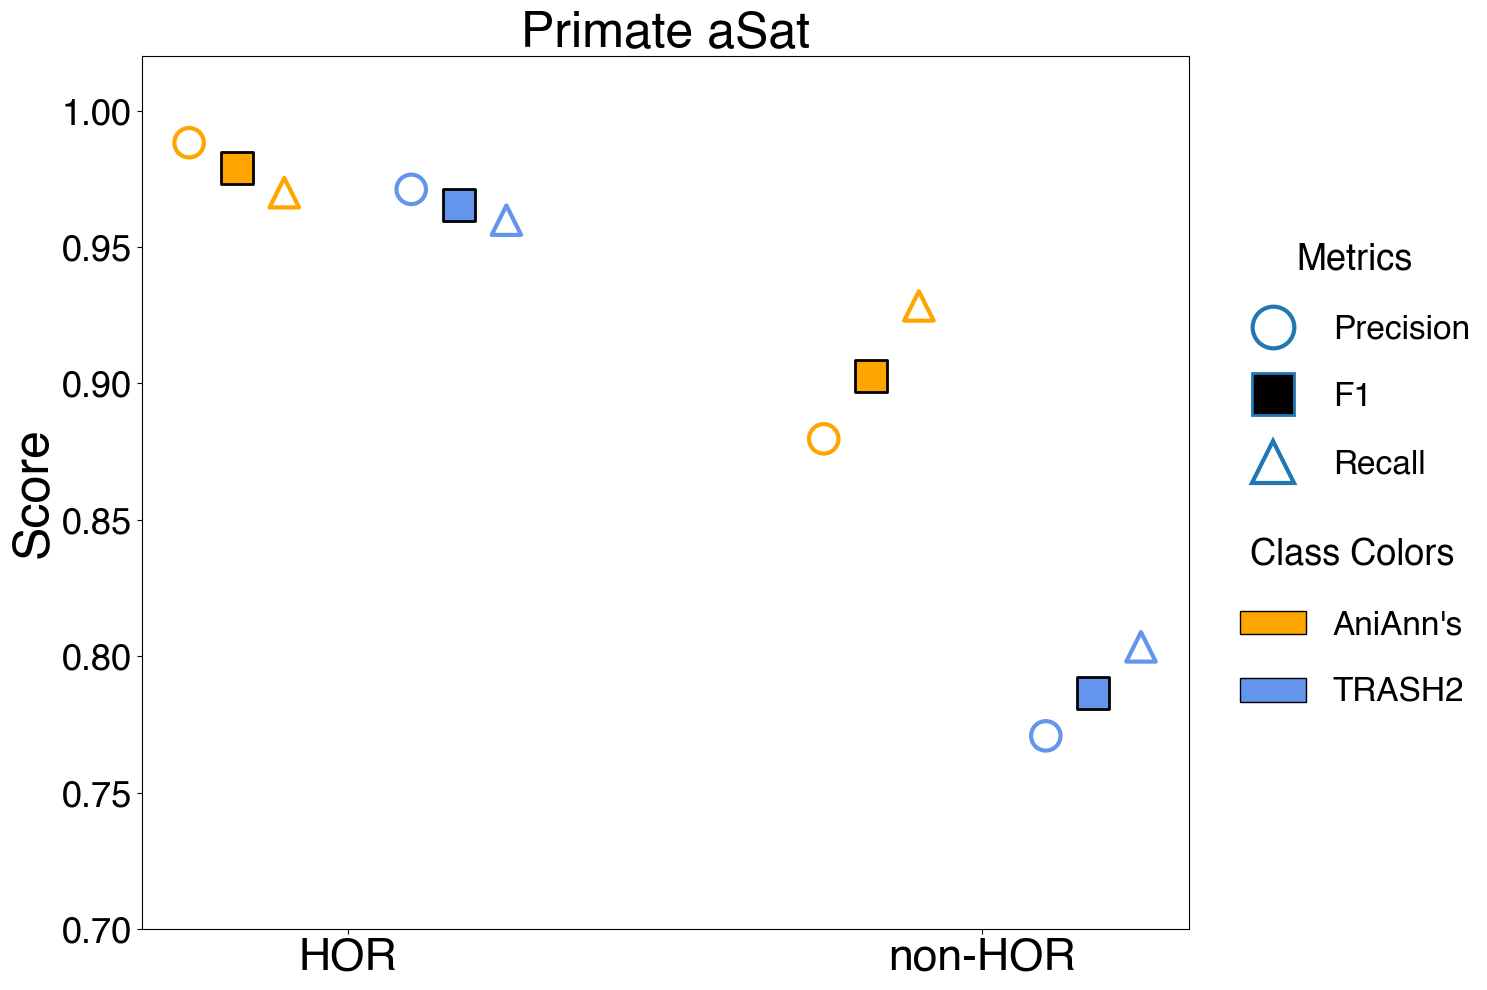

<Figure size 640x480 with 0 Axes>

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

import matplotlib as mpl

mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Helvetica"]
mpl.rcParams["axes.unicode_minus"] = False
# Data
groups = ["HOR", "non-HOR"]

values = np.array([
    [0.9882181016290393, 0.9699185614698026, 0.9789828234292907],
    [0.9711333697467664, 0.9598424718972429, 0.9654549104726521], 
    [0.8797137430237636, 0.9284118536040475, 0.90283564],
    [0.7708733645471935, 0.8034872677096213, 0.78657059], 
])

class_colors = ["orange", "cornflowerblue", "orange", "cornflowerblue"]

group_centers = np.array([0.0, 2.0])
intra_delta = 0.35

x_positions = np.array([
    group_centers[0] - intra_delta,
    group_centers[0] + intra_delta,
    group_centers[1] - intra_delta,
    group_centers[1] + intra_delta,
])

metric_offsets = {"Precision": -0.15, "F1": 0.0, "Recall": 0.15}
markers = {"Precision": "o", "F1": "s", "Recall": "^"}

fig, ax = plt.subplots(figsize=(15, 10))

# Larger scatter points
for i in range(len(values)):
    ax.scatter(
        x_positions[i] + metric_offsets["Precision"],
        values[i, 0],
        marker="o",
        s=450,
        facecolors="none",
        edgecolors=class_colors[i],
        linewidths=3,
    )
    ax.scatter(
        x_positions[i] + metric_offsets["F1"],
        values[i, 2],
        marker="s",
        s=550,
        color=class_colors[i],
        edgecolors="black",
        linewidths=2,
    )
    ax.scatter(
        x_positions[i] + metric_offsets["Recall"],
        values[i, 1],
        marker="^",
        s=450,
        facecolors="none",
        edgecolors=class_colors[i],
        linewidths=3,
    )

# Axes
ax.set_ylabel("Score", fontsize=36)
ax.set_ylim(0.7, 1.02)
ax.set_xticks(group_centers)
ax.set_xticklabels(groups, fontsize=32)
ax.set_title("Primate aSat", fontsize=36)
ax.tick_params(axis="y", labelsize=26)


# ----- BIG Metric Legend -----
metric_handles = [
    Line2D([0], [0], marker="o", linestyle="None",
           markerfacecolor="none", markeredgewidth=3,
           markersize=30, label="Precision"),
    Line2D([0], [0], marker="s", linestyle="None",
           markerfacecolor="black", markeredgewidth=2,
           markersize=30, label="F1"),
    Line2D([0], [0], marker="^", linestyle="None",
           markerfacecolor="none", markeredgewidth=3,
           markersize=30, label="Recall"),
]

metric_legend = ax.legend(
    handles=metric_handles,
    loc="center left",
    bbox_to_anchor=(1.02, 0.65),
    frameon=False,
    title="Metrics",
    title_fontsize=26,
    fontsize=24,
    labelspacing=1.1,
)

# ----- BIG Class Color Legend -----
class_handles = [
    Patch(facecolor="orange", edgecolor="black", label="AniAnn's"),
    Patch(facecolor="cornflowerblue", edgecolor="black", label="TRASH2"),
]

ax.add_artist(metric_legend)
ax.legend(
    handles=class_handles,
    loc="center left",
    bbox_to_anchor=(1.02, 0.35),
    frameon=False,
    title="Class Colors",
    title_fontsize=26,
    fontsize=24,
    labelspacing=1.1,
)

plt.tight_layout()
plt.show()
plt.savefig("primate_aSat_metrics.png", format="png", bbox_inches="tight")

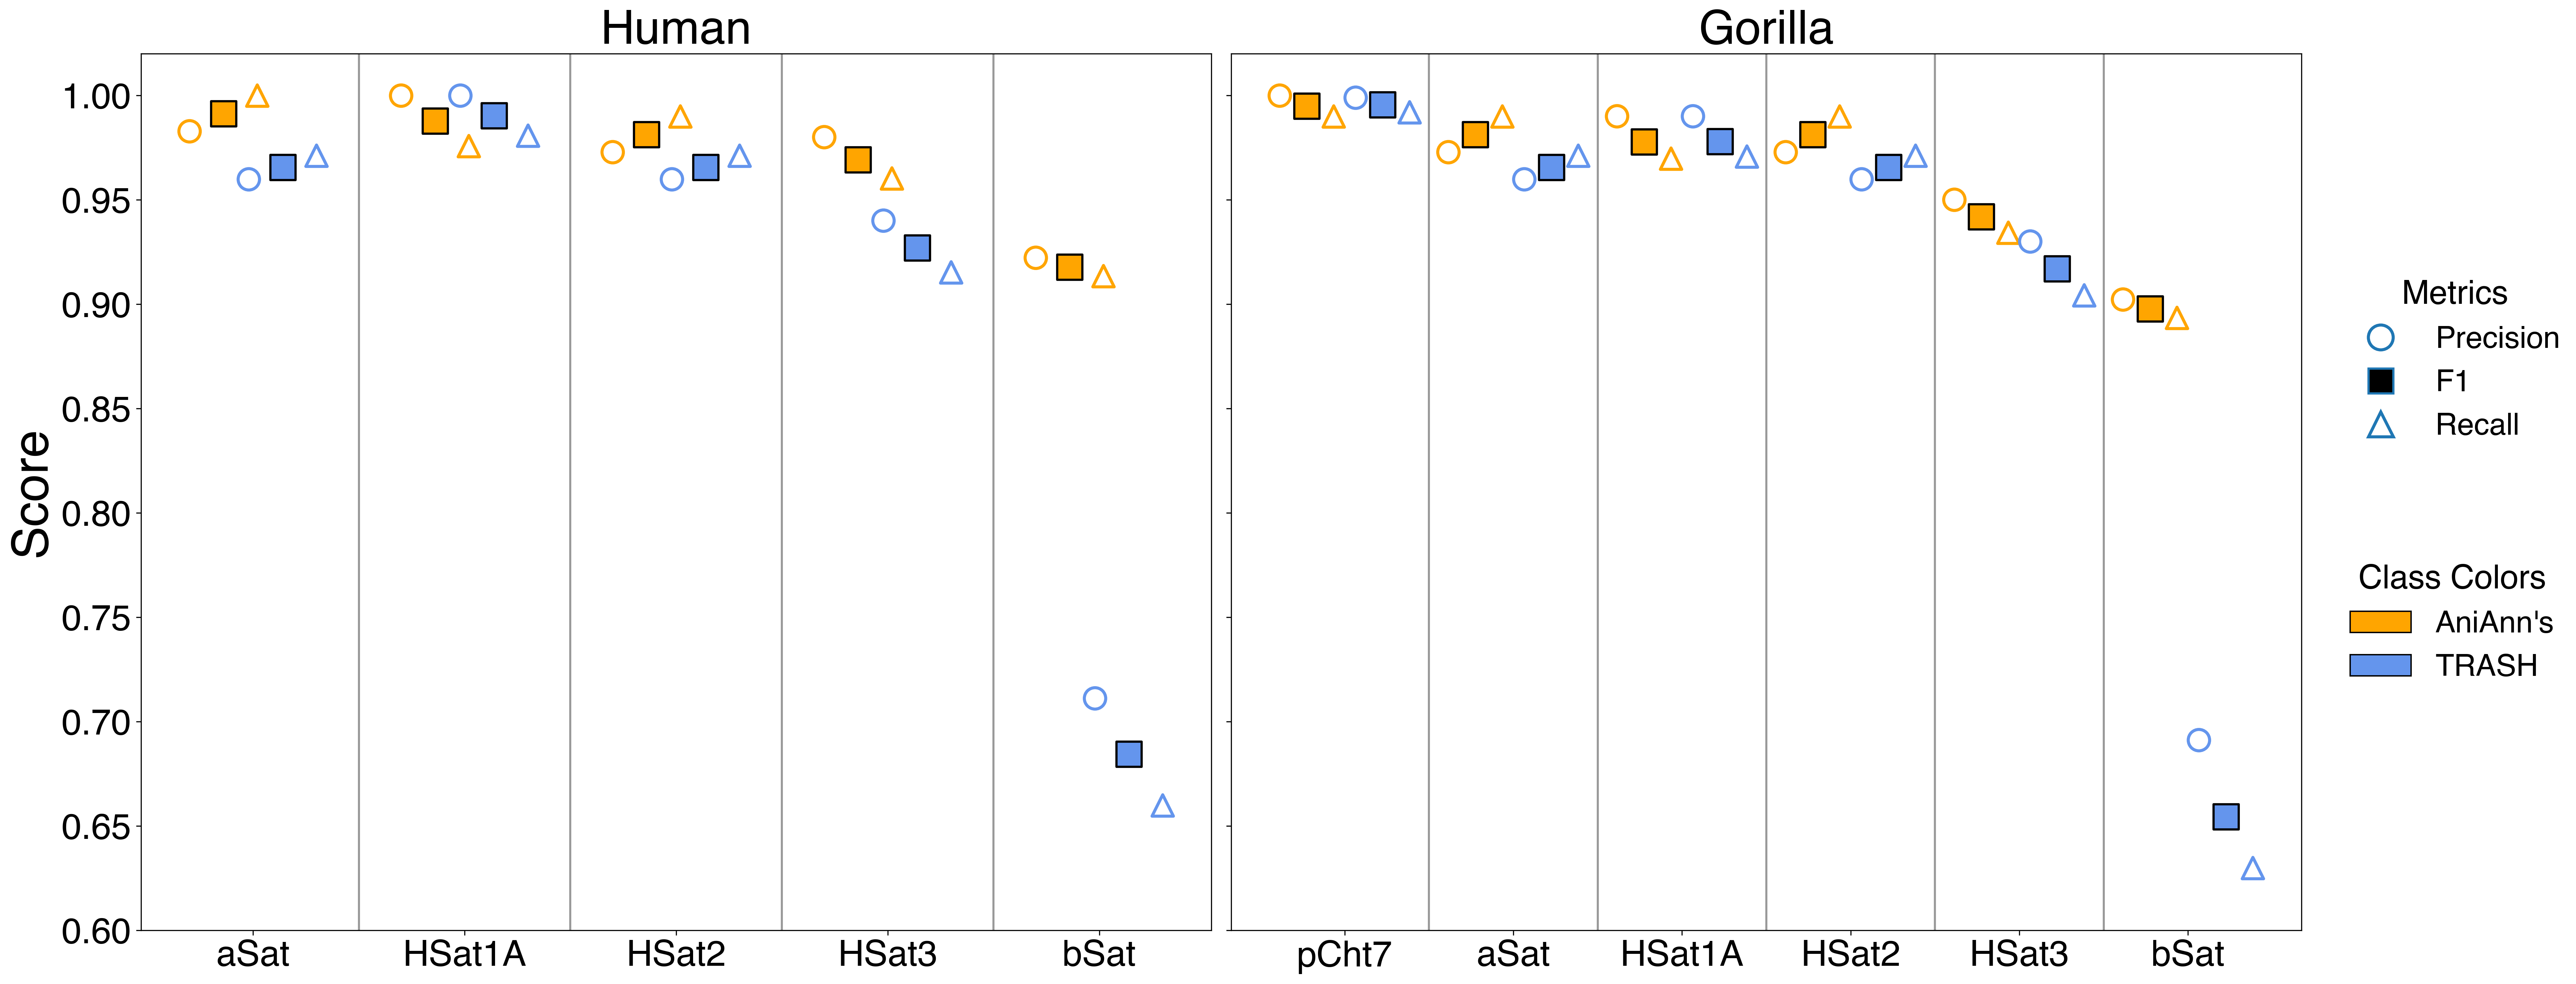

In [34]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib as mpl

# ---- Style ----
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Helvetica"]
mpl.rcParams["axes.unicode_minus"] = False

metric_offsets = {"Precision": -0.32, "F1": 0.0, "Recall": 0.32}
prec_size, f1_size, rec_size = 240, 340, 240

def plot_panel(ax, groups, values, title, intra_delta=0.28, show_legend=False):
    n_groups = len(groups)
    group_centers = np.arange(n_groups) * 2.0

    x_positions = []
    for gc in group_centers:
        x_positions.append(gc - intra_delta)
        x_positions.append(gc + intra_delta)
    x_positions = np.array(x_positions)

    class_colors = ["orange", "cornflowerblue"] * n_groups

    # vertical separators
    for x in (group_centers[:-1] + group_centers[1:]) / 2:
        ax.axvline(x, color="0.6", linewidth=1.5, zorder=0)

    for i in range(len(values)):
        ax.scatter(
            x_positions[i] + metric_offsets["Precision"],
            values[i, 0],
            marker="o", s=prec_size,
            facecolors="none",
            edgecolors=class_colors[i],
            linewidths=2.2,
        )
        ax.scatter(
            x_positions[i] + metric_offsets["F1"],
            values[i, 2],
            marker="s", s=f1_size,
            color=class_colors[i],
            edgecolors="black",
            linewidths=1.6,
        )
        ax.scatter(
            x_positions[i] + metric_offsets["Recall"],
            values[i, 1],
            marker="^", s=rec_size,
            facecolors="none",
            edgecolors=class_colors[i],
            linewidths=2.2,
        )

    ax.set_xticks(group_centers)
    ax.set_xticklabels(groups, fontsize=26)
    ax.set_ylim(0.6, 1.02)
    ax.set_title(title, fontsize=34)
    ax.tick_params(axis="y", labelsize=26)

    if show_legend:
        metric_handles = [
            Line2D([0], [0], marker="o", linestyle="None",
                   markerfacecolor="none", markeredgewidth=2.2,
                   markersize=18, label="Precision"),
            Line2D([0], [0], marker="s", linestyle="None",
                   markerfacecolor="black", markeredgewidth=1.6,
                   markersize=18, label="F1"),
            Line2D([0], [0], marker="^", linestyle="None",
                   markerfacecolor="none", markeredgewidth=2.2,
                   markersize=18, label="Recall"),
        ]

        metric_legend = ax.legend(
            handles=metric_handles,
            loc="center left",
            bbox_to_anchor=(1.02, 0.65),
            frameon=False,
            title="Metrics",
            title_fontsize=24,
            fontsize=22,
        )

        class_handles = [
            Patch(facecolor="orange", edgecolor="black", label="AniAnn's"),
            Patch(facecolor="cornflowerblue", edgecolor="black", label="TRASH"),
        ]

        ax.add_artist(metric_legend)
        ax.legend(
            handles=class_handles,
            loc="center left",
            bbox_to_anchor=(1.02, 0.35),
            frameon=False,
            title="Class Colors",
            title_fontsize=24,
            fontsize=22,
        )

# ---- Data ----
human_groups = ["aSat", "HSat1A", "HSat2", "HSat3", "bSat"]
human_values = np.array([
    [0.9828, 0.9999, 0.9913], [0.9598, 0.9711, 0.9655],
    [0.9999, 0.9757, 0.9877], [0.9999, 0.9807, 0.9903],
    [0.9728, 0.9899, 0.9813], [0.9598, 0.9711, 0.9655],
    [0.9800, 0.9602, 0.9692], [0.9400, 0.9152, 0.9269],
    [0.9222, 0.9134, 0.9178], [0.7111, 0.6598, 0.6845],
])

gorilla_groups = ["pCht7", "aSat", "HSat1A", "HSat2", "HSat3", "bSat"]
gorilla_values = np.array([
    [0.9999, 0.9899, 0.9949], [0.9989, 0.9919, 0.9955],
    [0.9728, 0.9899, 0.9813], [0.9598, 0.9711, 0.9655],
    [0.9900, 0.9697, 0.9777], [0.9900, 0.9707, 0.9780],
    [0.9728, 0.9899, 0.9813], [0.9598, 0.9711, 0.9655],
    [0.9500, 0.9342, 0.9419], [0.9300, 0.9042, 0.9169],
    [0.9022, 0.8934, 0.8978], [0.6911, 0.6298, 0.6545],
])

# ---- Figure: long horizontal layout ----
fig, (ax_h, ax_g) = plt.subplots(
    1, 2, figsize=(26, 10), sharey=True, dpi=300
)

plot_panel(ax_h, human_groups, human_values, "Human", show_legend=False)
plot_panel(ax_g, gorilla_groups, gorilla_values, "Gorilla", intra_delta=0.45, show_legend=True)

ax_h.set_ylabel("Score", fontsize=36)

plt.tight_layout()
plt.show()


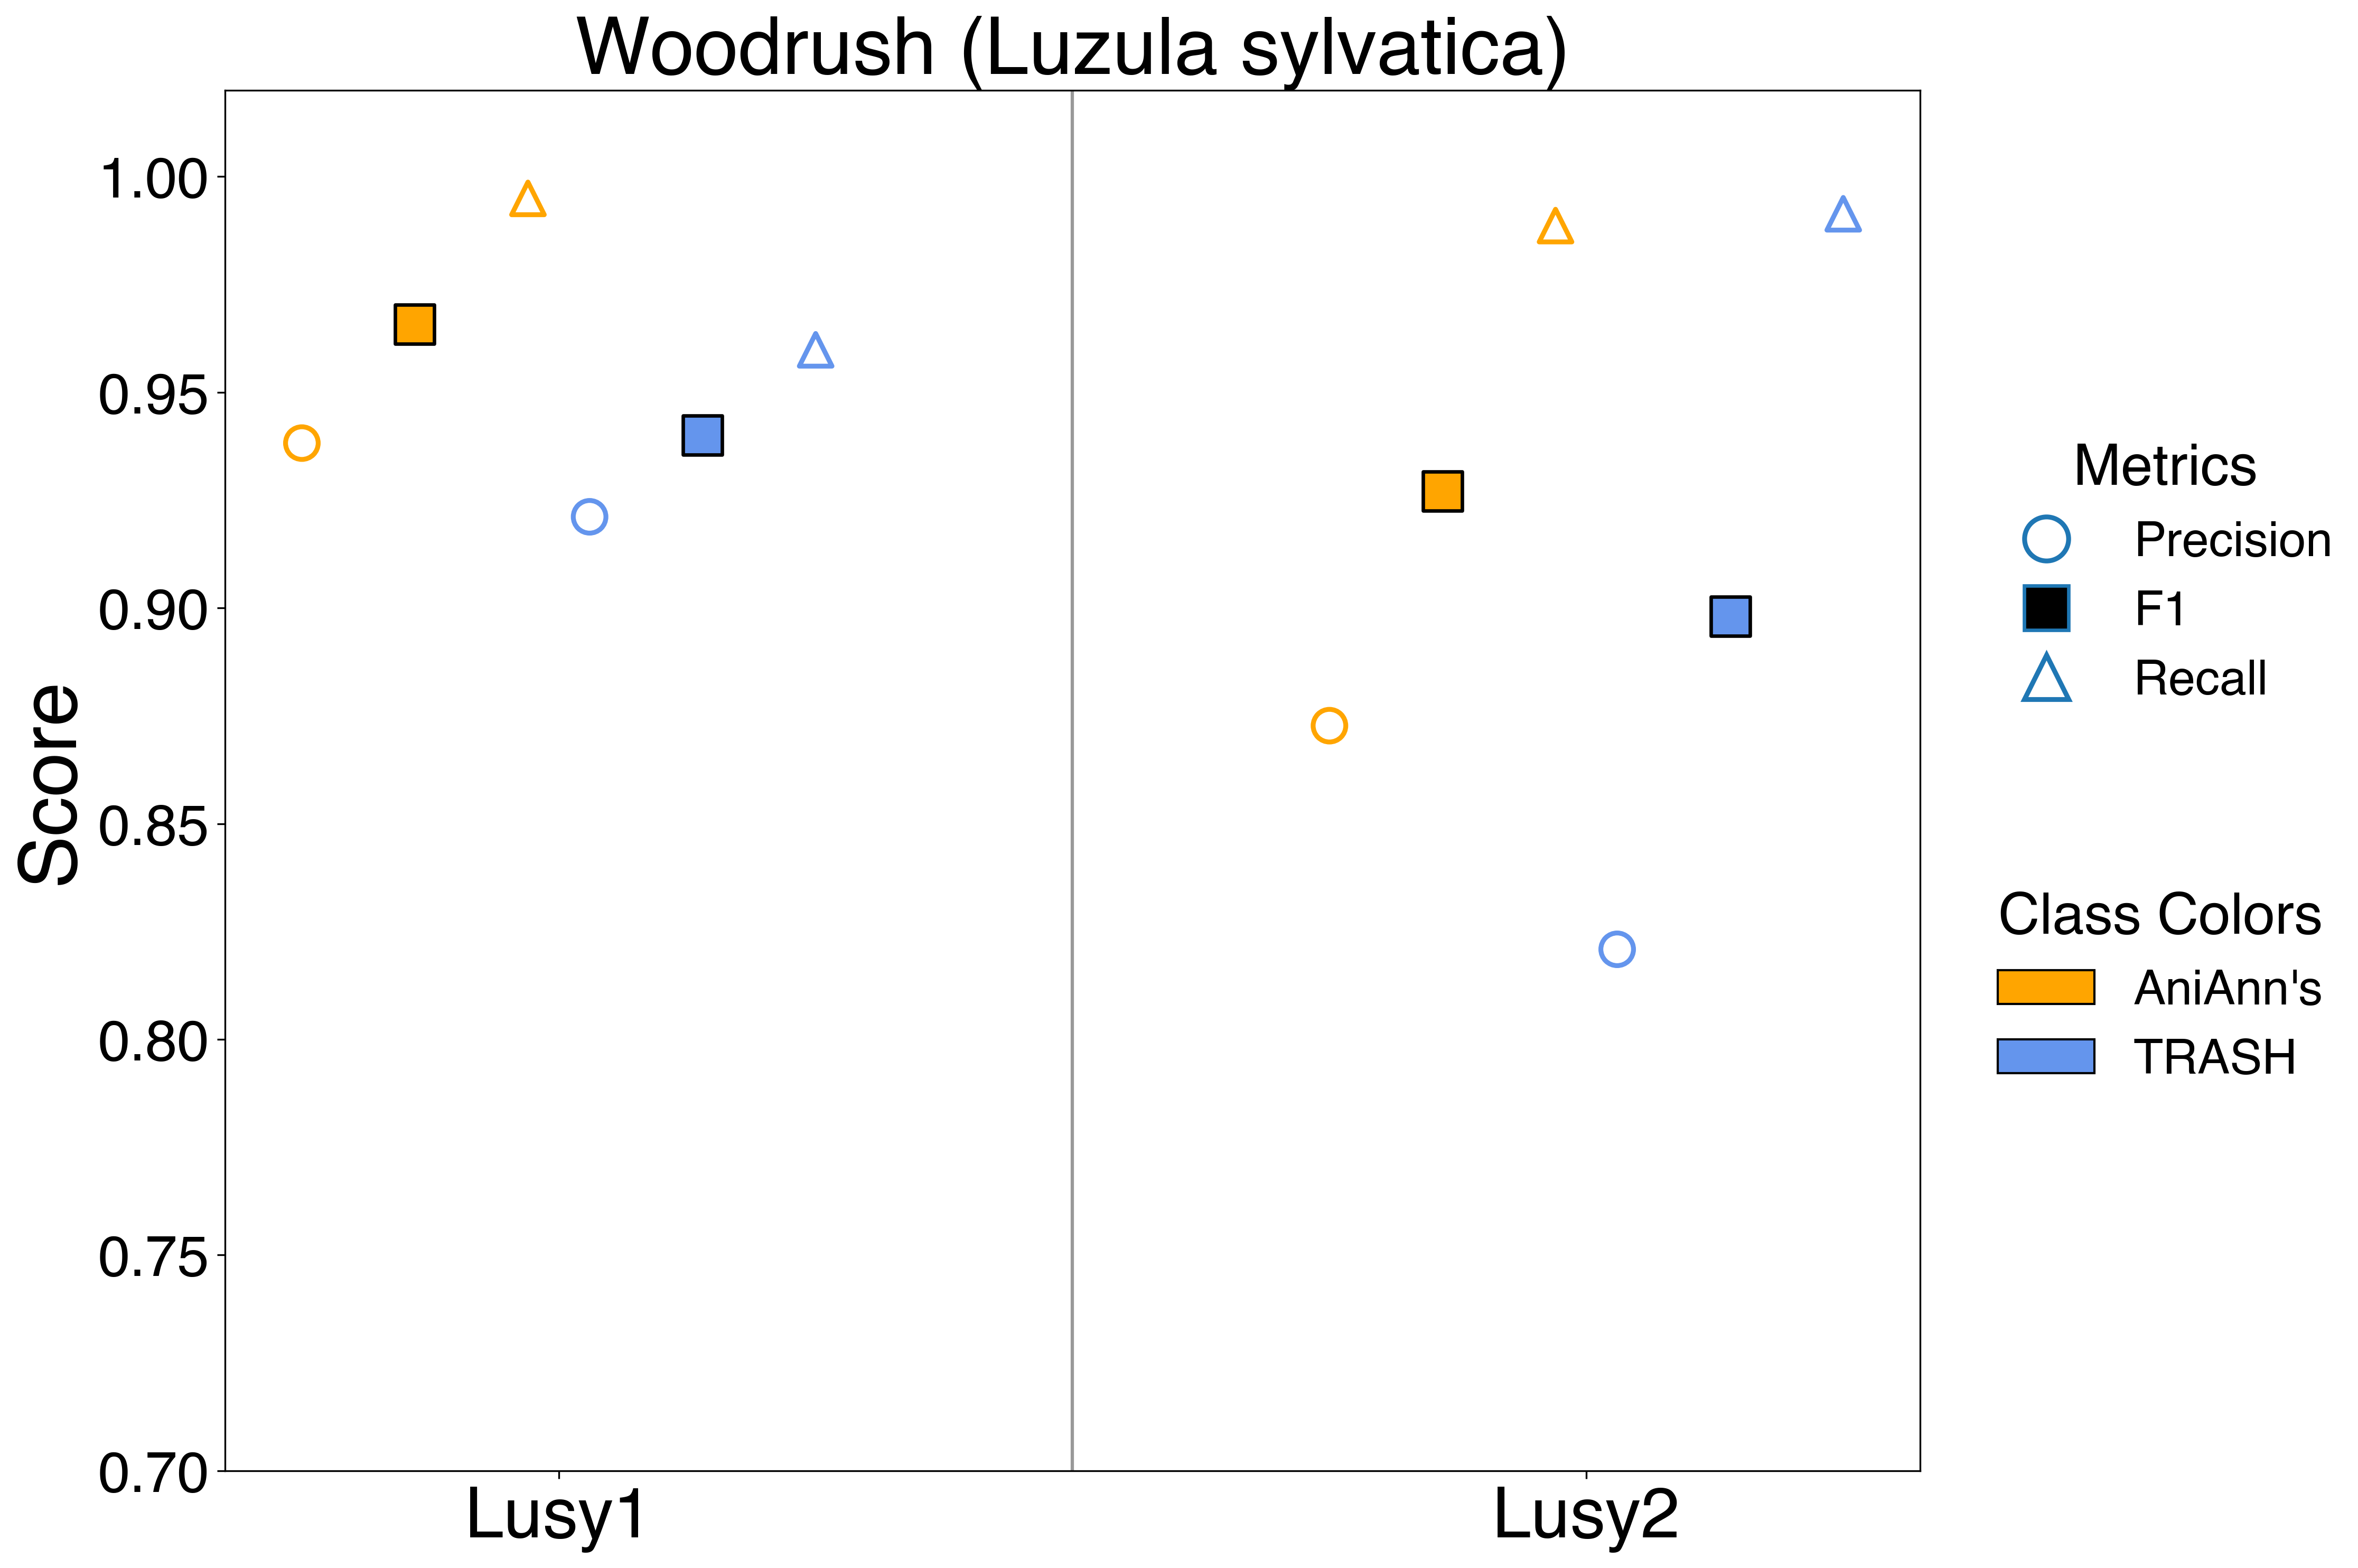

In [35]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib as mpl

# ---- Style ----
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.sans-serif"] = ["Helvetica"]
mpl.rcParams["axes.unicode_minus"] = False

# ---- Data ----
groups = ["Lusy1", "Lusy2"]

# Rows are (AniAnn, TRASH) for each group
# each row: [Precision, Recall, F1]
values = np.array([
    [0.9382181016290393, 0.9949442123949229, 0.9657488803792121],  # Lusy1 AniAnn
    [0.9211333697467664, 0.9598424718972429, 0.9400896183674695],  # Lusy1 TRASH
    [0.8727137430237636, 0.9886390271826070, 0.9270664644792139],  # Lusy2 AniAnn
    [0.8208733645471935, 0.9913775463862830, 0.8981045804738703],  # Lusy2 TRASH
])

# Colors alternating AniAnn / TRASH
class_colors = [
    "orange", "cornflowerblue",
    "orange", "cornflowerblue",
]

# ---- Layout ----
group_centers = np.array([0.0, 2.0])
intra_delta = 0.28

x_positions = np.array([
    group_centers[0] - intra_delta,
    group_centers[0] + intra_delta,
    group_centers[1] - intra_delta,
    group_centers[1] + intra_delta,
])

metric_offsets = {"Precision": -0.22, "F1": 0.0, "Recall": 0.22}

prec_size = 220
f1_size   = 320
rec_size  = 220

fig, ax = plt.subplots(figsize=(15, 10), dpi=300)

# ---- Vertical separator between Lusy1 / Lusy2 ----
ax.axvline(
    (group_centers[0] + group_centers[1]) / 2,
    color="0.6",
    linewidth=1.5,
    zorder=0
)

# ---- Points ----
for i in range(len(values)):
    # Precision
    ax.scatter(
        x_positions[i] + metric_offsets["Precision"],
        values[i, 0],
        marker="o",
        s=prec_size,
        facecolors="none",
        edgecolors=class_colors[i],
        linewidths=2.2,
        zorder=5,
    )
    # F1
    ax.scatter(
        x_positions[i] + metric_offsets["F1"],
        values[i, 2],
        marker="s",
        s=f1_size,
        color=class_colors[i],
        edgecolors="black",
        linewidths=1.6,
        zorder=6,
    )
    # Recall
    ax.scatter(
        x_positions[i] + metric_offsets["Recall"],
        values[i, 1],
        marker="^",
        s=rec_size,
        facecolors="none",
        edgecolors=class_colors[i],
        linewidths=2.2,
        zorder=5,
    )

# ---- Axes ----
ax.set_ylabel("Score", fontsize=36)
ax.set_ylim(0.70, 1.02)
ax.set_xticks(group_centers)
ax.set_xticklabels(groups, fontsize=32)
ax.set_title("Woodrush (Luzula sylvatica)", fontsize=36)
ax.tick_params(axis="y", labelsize=26)

# ---- Metric Legend ----
metric_handles = [
    Line2D([0], [0], marker="o", linestyle="None",
           markerfacecolor="none", markeredgewidth=2.2,
           markersize=20, label="Precision"),
    Line2D([0], [0], marker="s", linestyle="None",
           markerfacecolor="black", markeredgewidth=1.6,
           markersize=20, label="F1"),
    Line2D([0], [0], marker="^", linestyle="None",
           markerfacecolor="none", markeredgewidth=2.2,
           markersize=20, label="Recall"),
]

metric_legend = ax.legend(
    handles=metric_handles,
    loc="center left",
    bbox_to_anchor=(1.02, 0.65),
    frameon=False,
    title="Metrics",
    title_fontsize=26,
    fontsize=22,
)

# ---- Class Color Legend ----
class_handles = [
    Patch(facecolor="orange", edgecolor="black", label="AniAnn's"),
    Patch(facecolor="cornflowerblue", edgecolor="black", label="TRASH"),
]

ax.add_artist(metric_legend)
ax.legend(
    handles=class_handles,
    loc="center left",
    bbox_to_anchor=(1.02, 0.35),
    frameon=False,
    title="Class Colors",
    title_fontsize=26,
    fontsize=22,
)

plt.tight_layout()
plt.show()
